# Differential gene expression over updated cell-types

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
})

here::i_am("differential/01_DEG_analysis_manual.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/12_Eomes_T_Mixl1/T_E75/code



In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/12_Eomes_T_Mixl1/T_E75/"

In [3]:
args = list()
args$sce = io$rna.sce
args$metadata = paste0(io$basedir, 'results/rna/mapping/manual/metadata_mapping_updated.txt.gz')
args$variable = 'celltype_updated'
args$outdir = paste0(io$basedir,"/results/rna/differential/celltype_updated")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [4]:
# Functions
# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.16)) +
    annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.5,
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
    
    
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [5]:
###############
## Load data ##
###############

# Load metadata
sample_metadata <- fread(args$metadata) %>%
   .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)] %>% 
   .[,variable := .[[args$variable]]]

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [6]:
nrow(sample_metadata)

[1] 4139

In [14]:
table(sample_metadata$celltype.mapped_mnn, sample_metadata$tdTom)

                                
                                 FALSE TRUE
  Allantois                          2    1
  Anterior_Primitive_Streak         28   61
  Blood_progenitors_1               44   38
  Blood_progenitors_2               63   70
  Caudal_epiblast                   66   94
  Caudal_Mesoderm                    7   14
  Caudal_neurectoderm                7    3
  Def._endoderm                     39   50
  Endothelium                        0    2
  Epiblast                         206  238
  Erythroid1                         2    2
  ExE_ectoderm                     410    3
  ExE_endoderm                      93    7
  ExE_mesoderm                      19   22
  Gut                               37   72
  Haematoendothelial_progenitors    85   84
  Intermediate_mesoderm             31   35
  Mesenchyme                       108  179
  Mixed_mesoderm                   121  205
  Nascent_mesoderm                 203  298
  Notochord                         21   19

In [19]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(sce, 
    id=colData(sce)[,c("variable", "sample", "tdTom")])

summed.filt <- summed[,summed$ncells >= 1]

In [20]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkSpecific(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom,
    average = 'median'
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [21]:
fwrite(de.results, file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [22]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

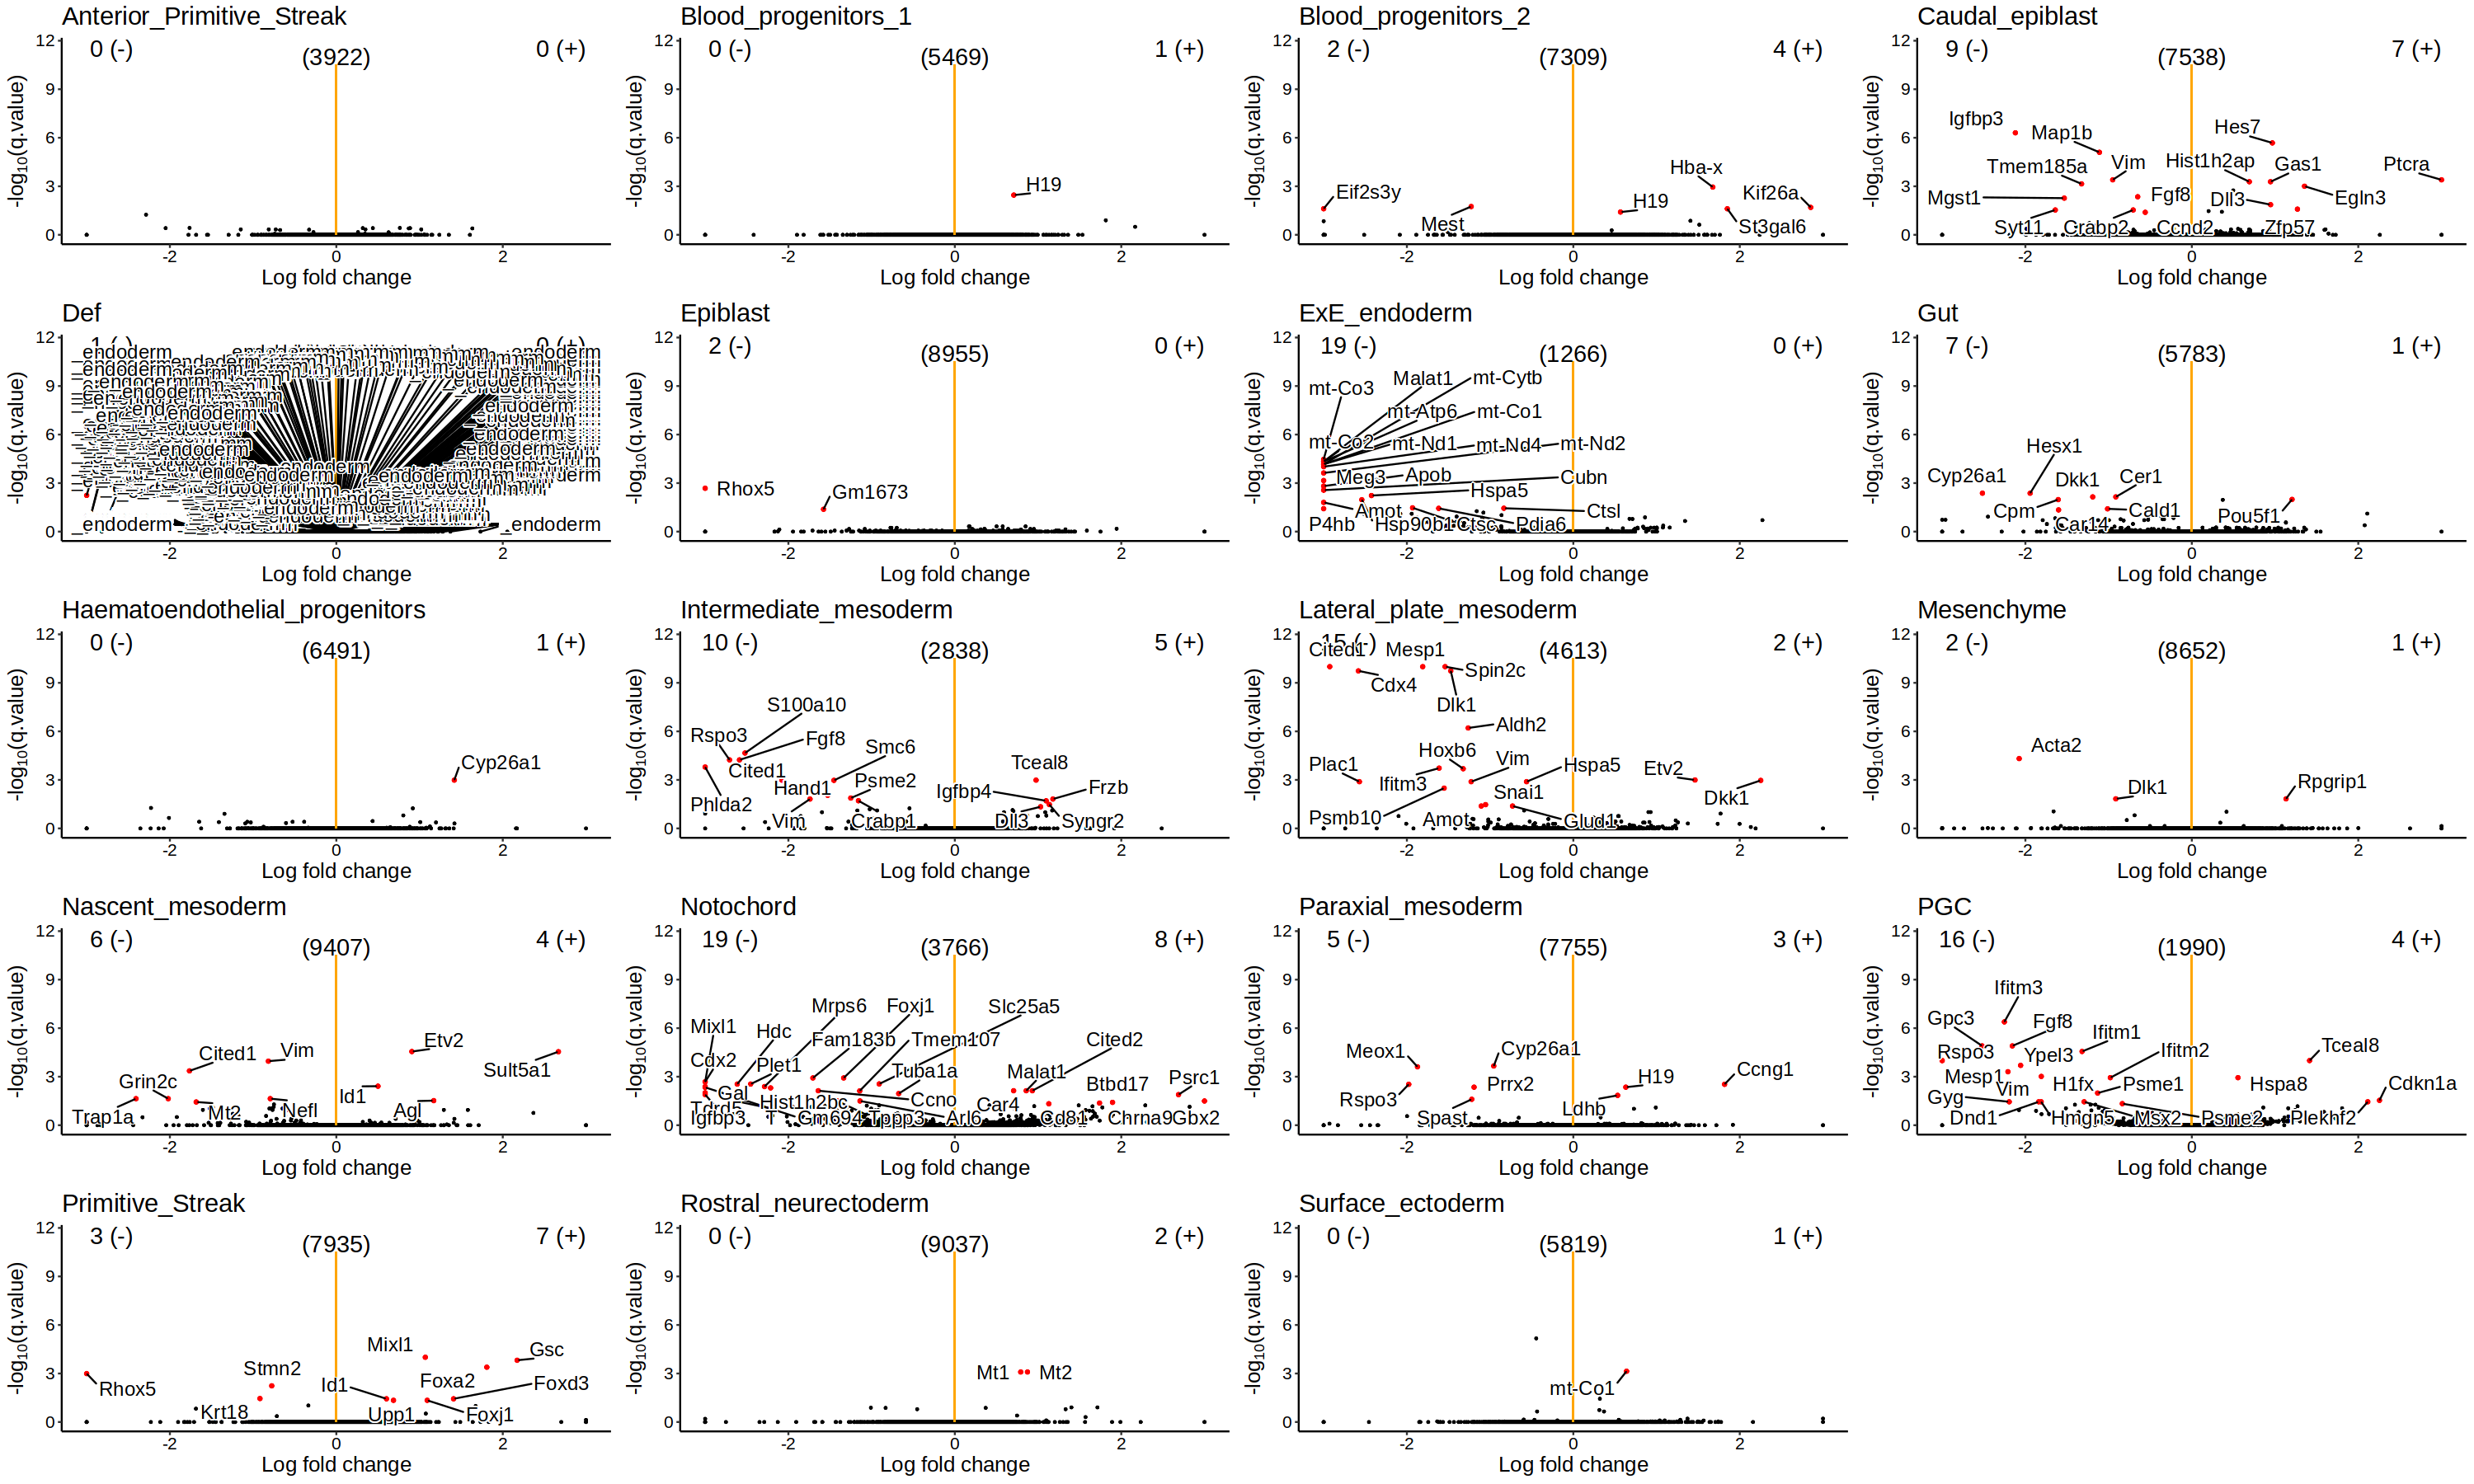

In [23]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=15)
combined_plot

In [ ]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

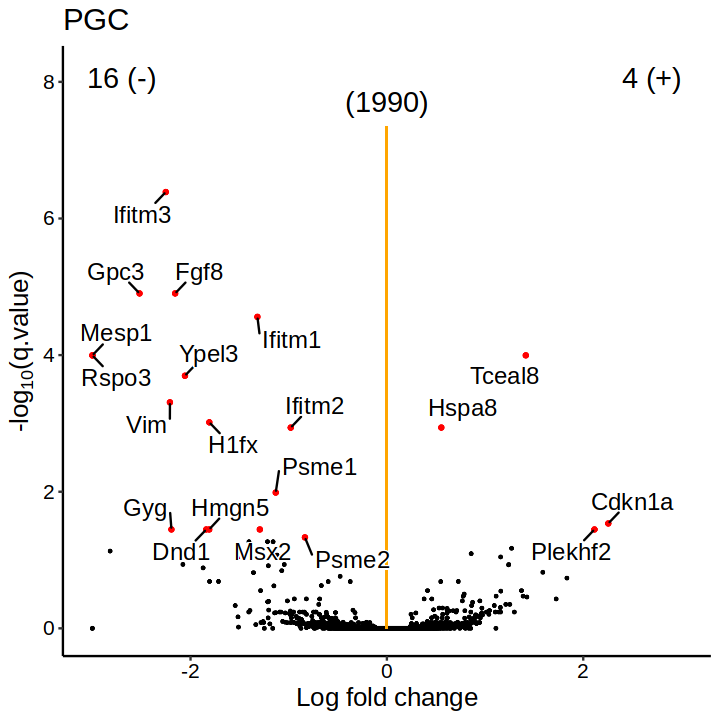

In [27]:
options(repr.plot.width=6, repr.plot.height=6)
gg_volcano_plot('PGC', ylim = 7, xlim = 3)

### Not specific but all genes

In [12]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    lfc = 0.5,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [23]:
fwrite(de.results, file.path(args$outdir, 'pseudoBulkAll.txt.gz'))

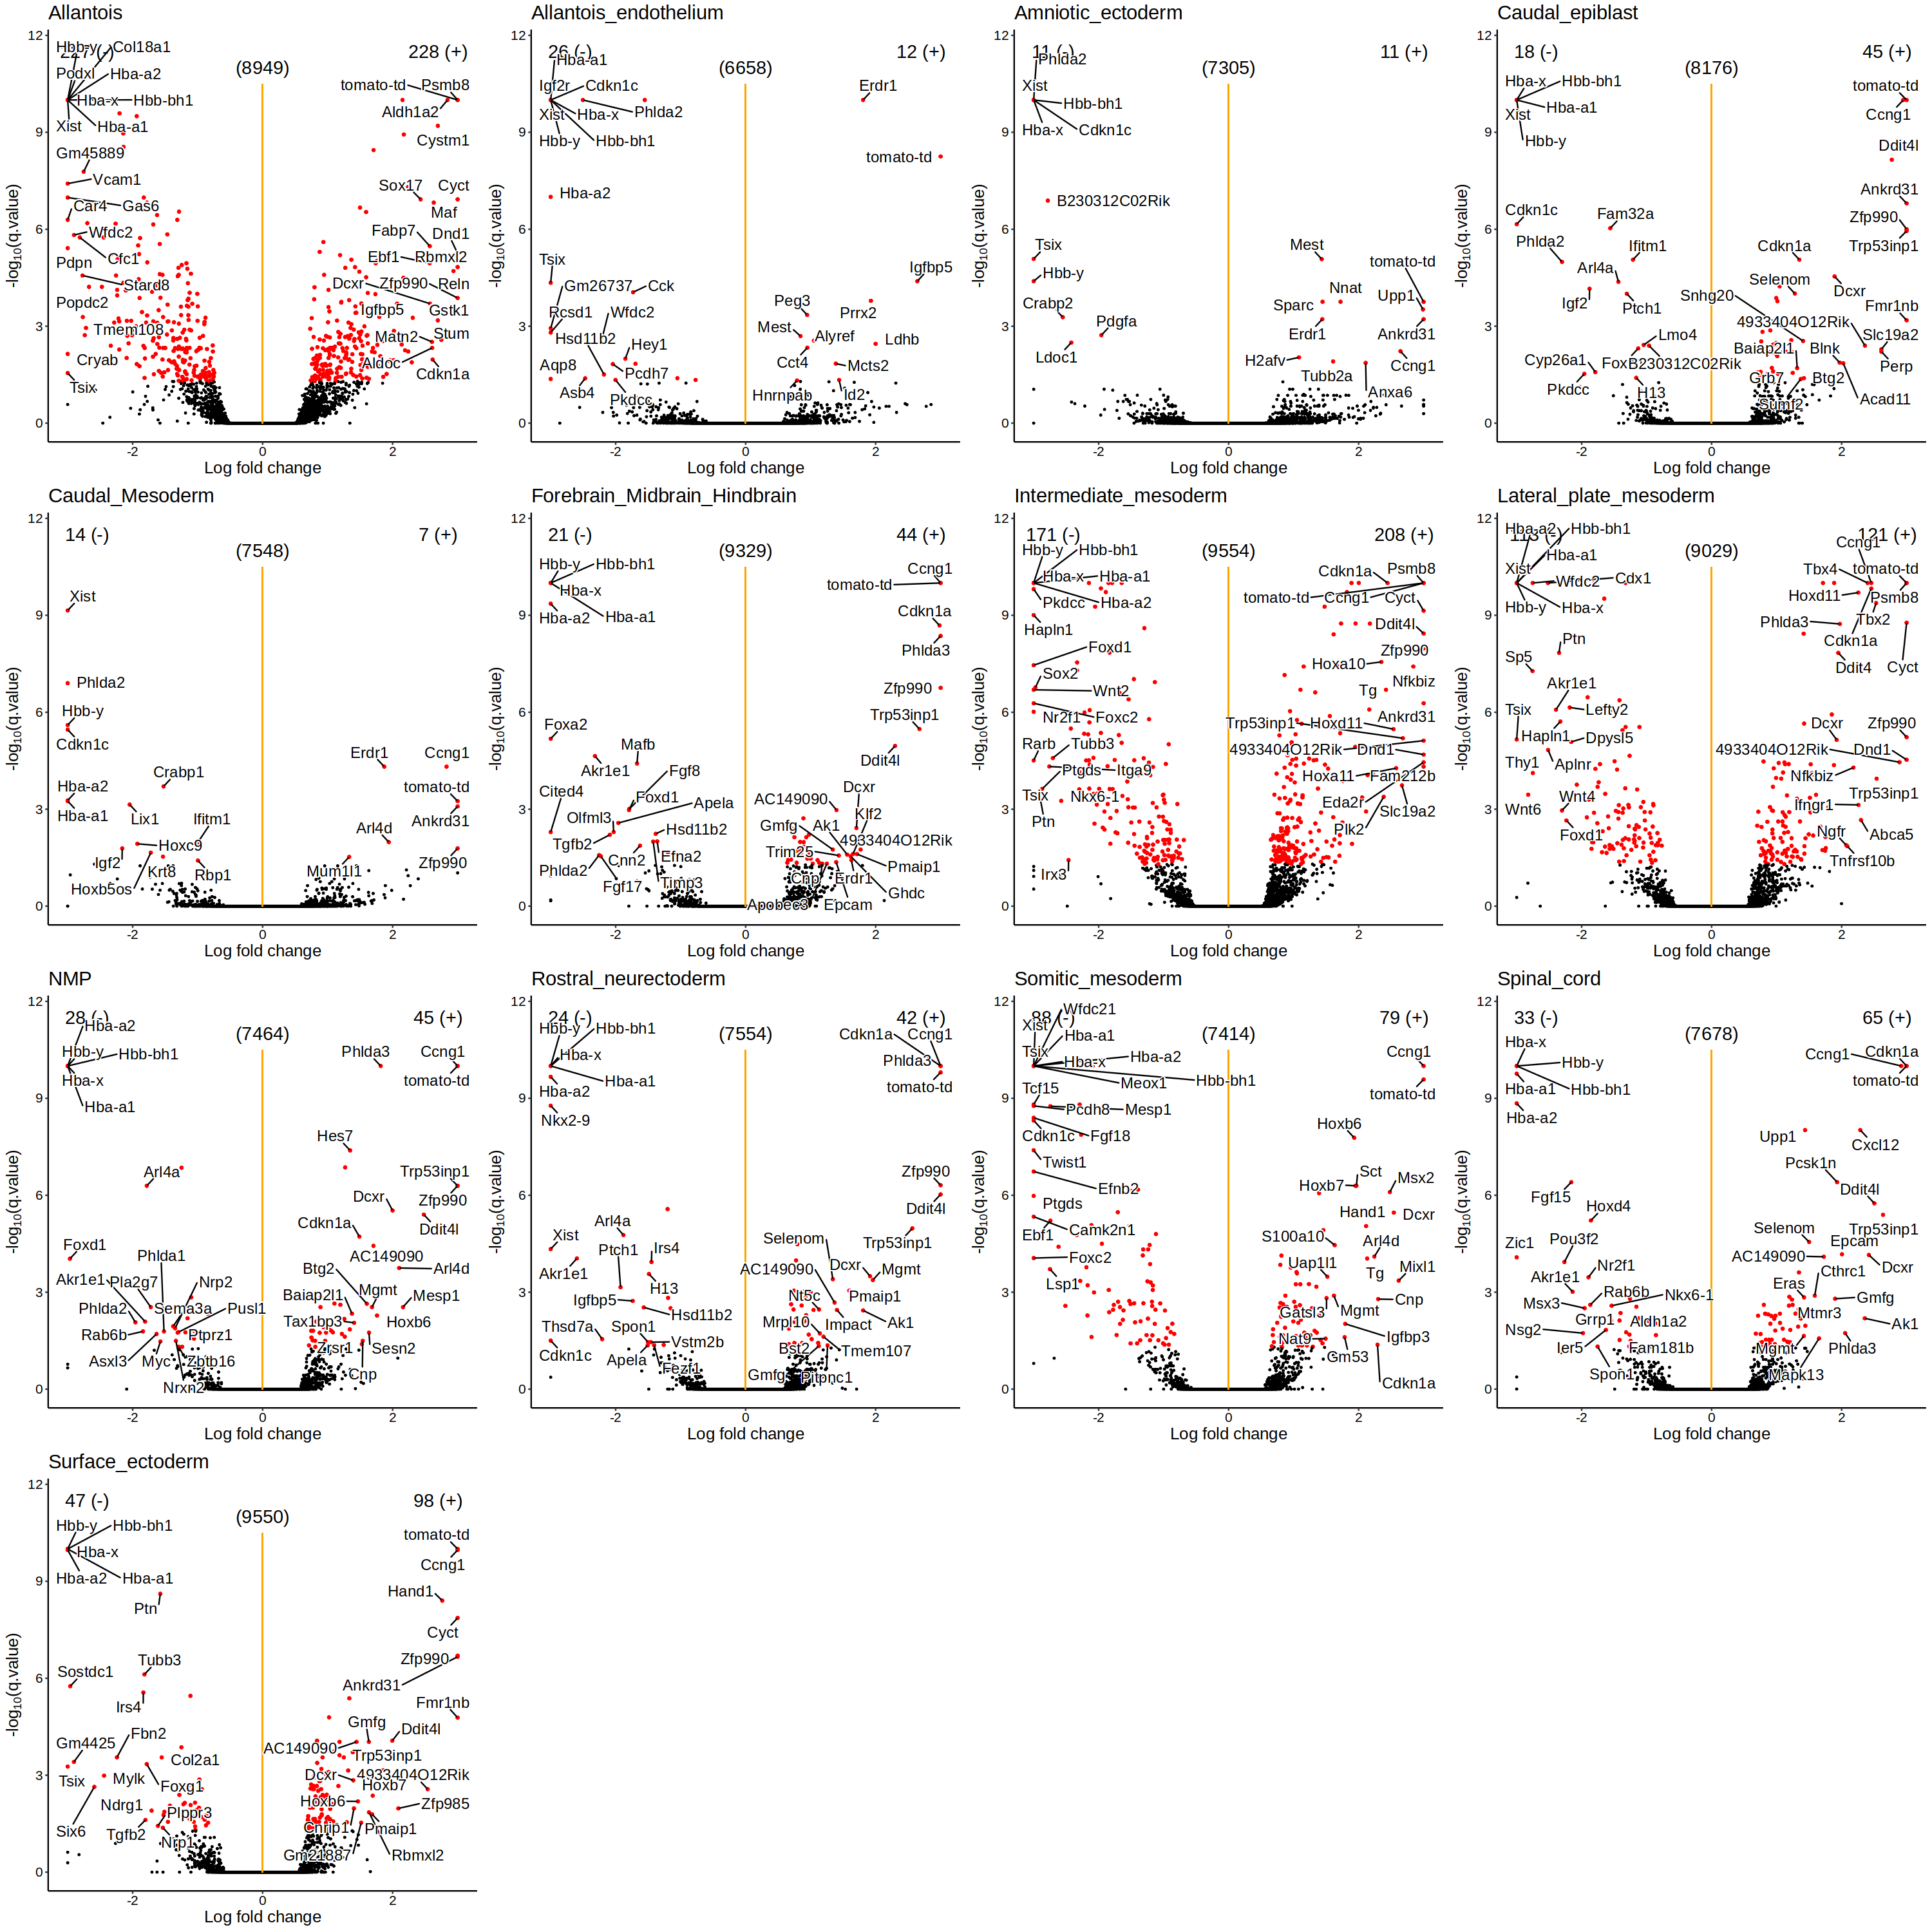

In [24]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

### Little test

In [5]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [75]:
head(de.results)

logFC,logCPM,F,PValue,padj_fdr,OtherAverage,gene,variable,sig
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>
2.4300800,4.693565,118.3691169,1.717675e-11,1.280956e-08,-0.38042566,Sox17,Allantois,TRUE
0.1141347,7.647249,1.4512978,8.572185e-01,1.000000e+00,0.09694575,Mrpl15,Allantois,FALSE
0.1685335,4.624626,0.8422278,7.643426e-01,1.000000e+00,0.11301293,Lypla1,Allantois,FALSE
-0.1891444,7.271503,3.4604979,2.925666e-01,7.569176e-01,-0.08013203,Tcea1,Allantois,FALSE
0.1165797,5.195631,0.5648115,1.000000e+00,1.000000e+00,0.18470133,Atp6v1h,Allantois,FALSE
0.2197346,6.039628,1.8795368,1.855267e-01,6.032989e-01,-0.08676637,Rb1cc1,Allantois,FALSE


In [83]:
plot_gene_UMAP = function(gene, sig_only=T){
    gene_i = gene
    tmp = sample_metadata %>% copy() %>% .[, c('umapX', 'umapY', 'variable')] %>% 
        merge(., de.results[gene==gene_i][,c('variable', 'sig', 'logFC', 'padj_fdr')], by='variable', all.x=TRUE) %>% 
        .[,sig := ifelse(padj_fdr < 0.05, TRUE, FALSE)] %>%  # significance only based on p-value instead of logFC too
        .[, color := logFC] %>%
        .[, logFC := ifelse(is.na(logFC), 0, logFC)]
    tmp = tmp[order(abs(logFC))]
    
    if(sig_only==T){
        tmp = tmp[, color := ifelse(sig==TRUE, logFC, 0)]        
    }
    
    p = ggplot(tmp, aes(umapX, umapY, color=color)) + 
            geom_point() +
            scale_color_gradient2(low='darkblue', mid='grey90', high='darkred') + 
            theme_void()
    return(p)
}

In [115]:
sce

class: SingleCellExperiment 
dim: 29453 28723 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(28723): SLX-20795_SITTH10_HKTG2DRXY#GTTCATTTCACCCTGT-1
  SLX-20795_SITTG11_HKTG2DRXY#ATAGAGACATATGGCT-1 ...
  SLX-20795_SITTB11_HKTG2DRXY#CTACCCATCTCGTGGG-1
  SLX-20795_SITTB11_HKTG2DRXY#AAAGGATAGGTACAAT-1
colData names(25): closest.cell_mnn sample ... pool variable
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

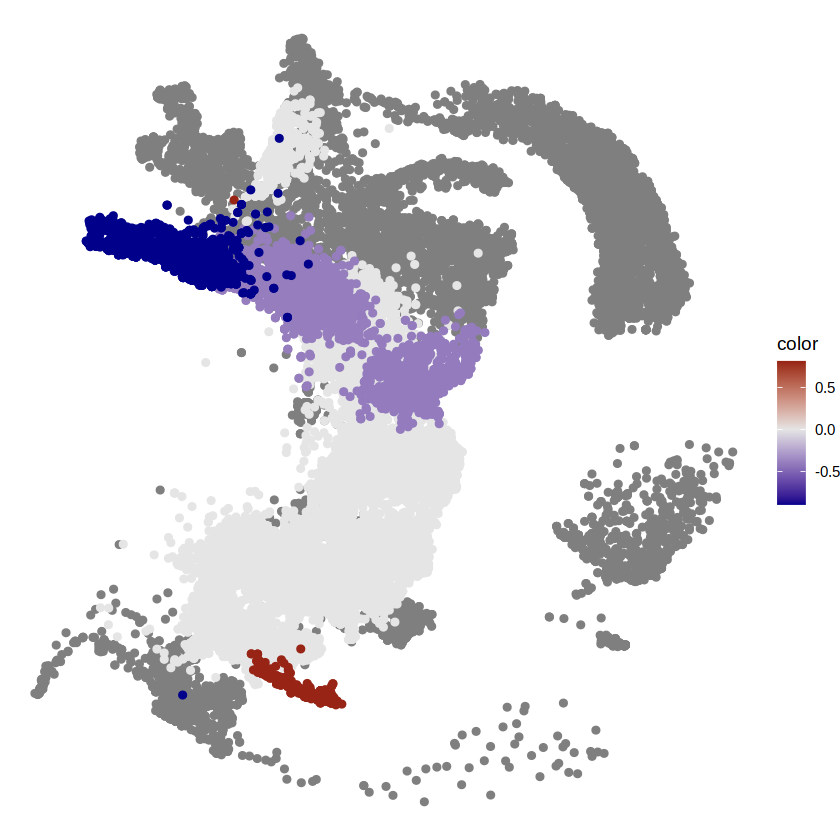

In [114]:
plot_gene_UMAP('Cald1', sig_only = T)

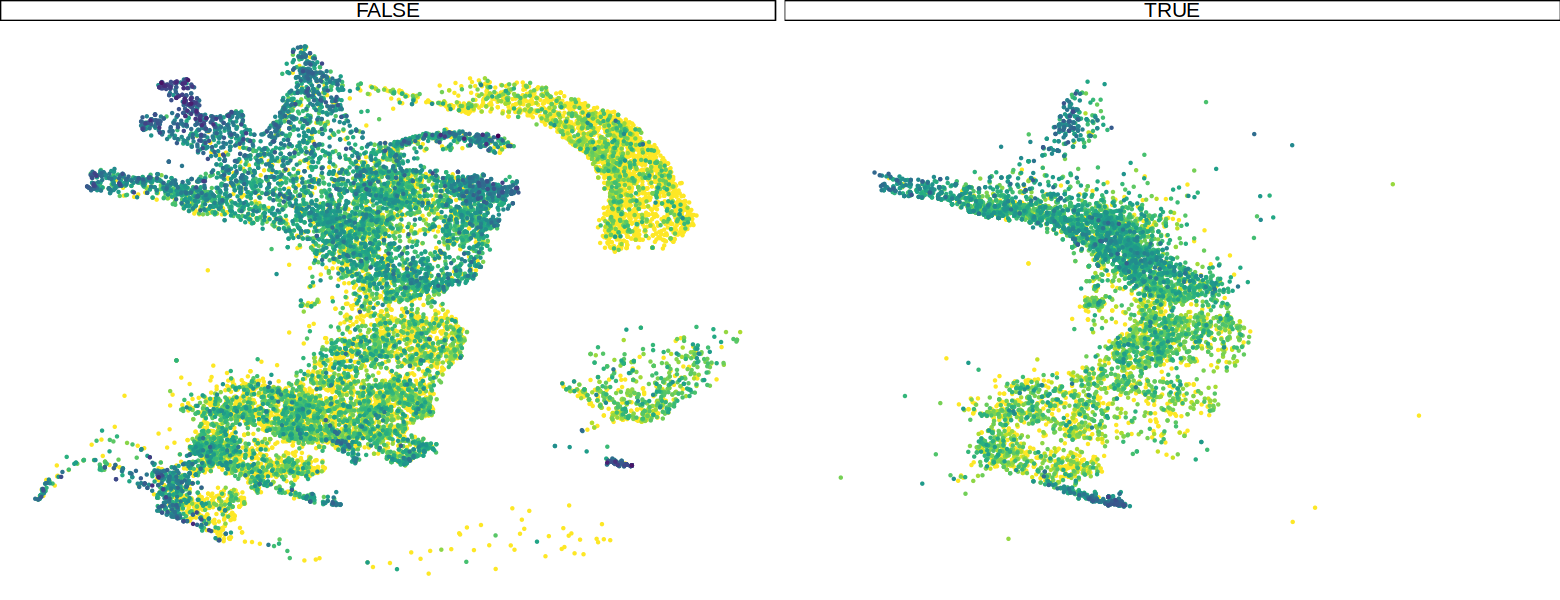

In [117]:
options(repr.plot.height=5, repr.plot.width=13)

tmp = as.data.table(sample_metadata) %>% .[,gene := as.vector(logcounts(sce['Cald1',]))] %>% 
    .[order(gene)]
p = ggplot(tmp , aes(x = umapX, y = umapY , col = gene)) +
  geom_point(size=0.2) + 
  viridis::scale_color_viridis(begin=1, end=0) +
  facet_wrap(~tdTom) +
  theme_void() + 
  theme(legend.position='none',
       strip.background=element_rect(fill=NA),
       text=element_text(size=15)) + 
  labs(x = "UMAP-1", y = "UMAP-2")
p

# Gene ontology

In [5]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [111]:
suppressPackageStartupMessages({
    library(biomaRt)
    library(limma)
    library(org.Mm.eg.db)
})

# mm10mart <- useMart(dataset = "mmusculus_gene_ensembl", biomart = "ensembl")
# mapping <- getBM(
#   attributes = c('hgnc_symbol', 'ensembl_gene_id', 'entrezgene_id', 'external_gene_name'), 
#   mart = mm10mart
# )
# mapping = as.data.table(mapping)
# fwrite(mapping, '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.07052024.txt')
mapping = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.07052024.txt')

In [242]:
genes = de.results[variable=='Allantois' & sig == TRUE & logFC <0, gene]

In [243]:
# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

'select()' returned 1:many mapping between keys and columns



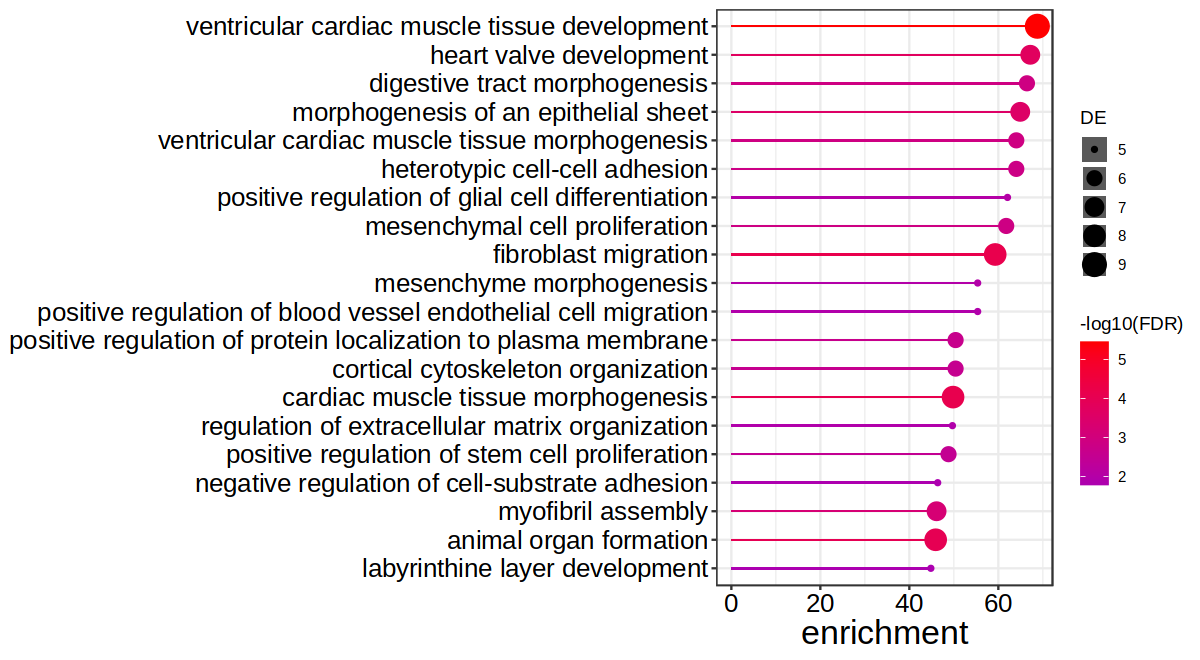

In [252]:
options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>%
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50] %>% .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))] %>% 
        head(20)
ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

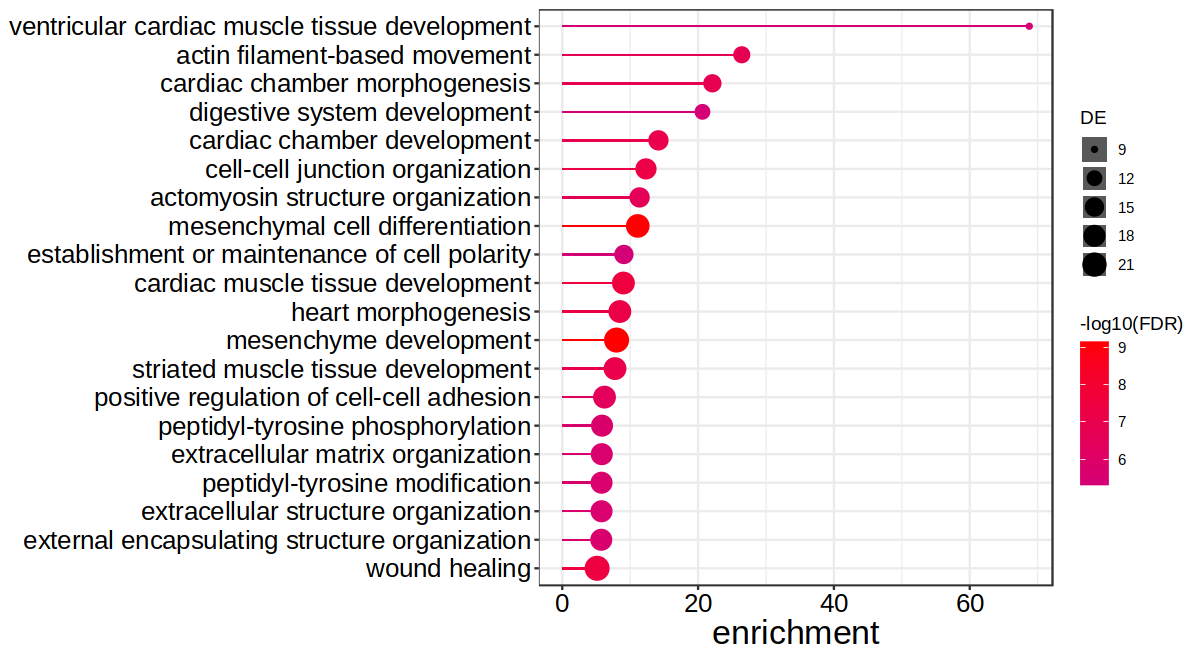

In [279]:
options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

In [280]:
genes = de.results[variable=='Allantois' & sig == TRUE & logFC > 0, gene]

In [281]:
# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

'select()' returned 1:many mapping between keys and columns



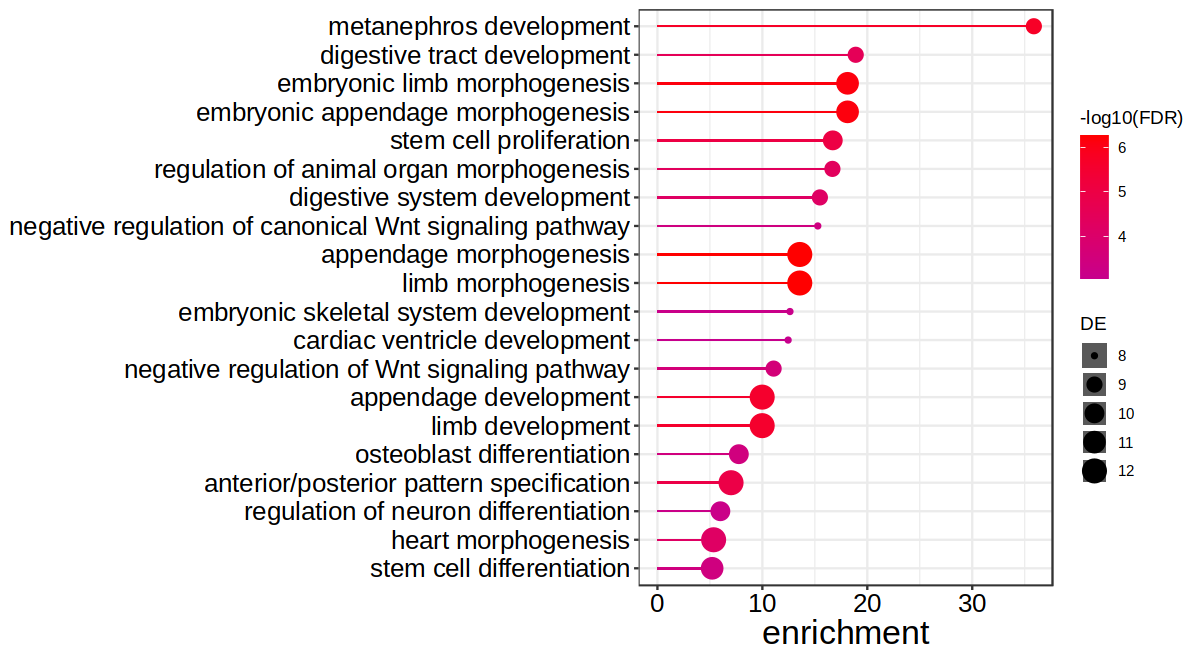

In [282]:
options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

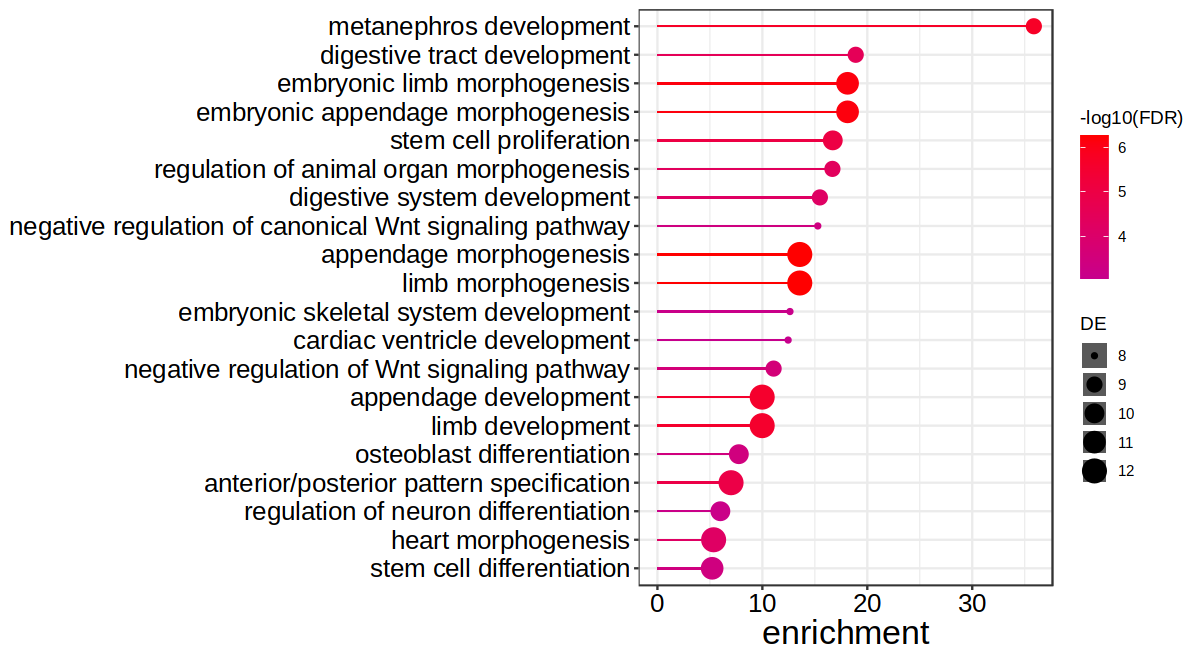

In [284]:
options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

In [285]:
genes = de.results[variable=='Intermediate_mesoderm' & sig == TRUE & logFC <0, gene]

In [286]:
# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

'select()' returned 1:many mapping between keys and columns



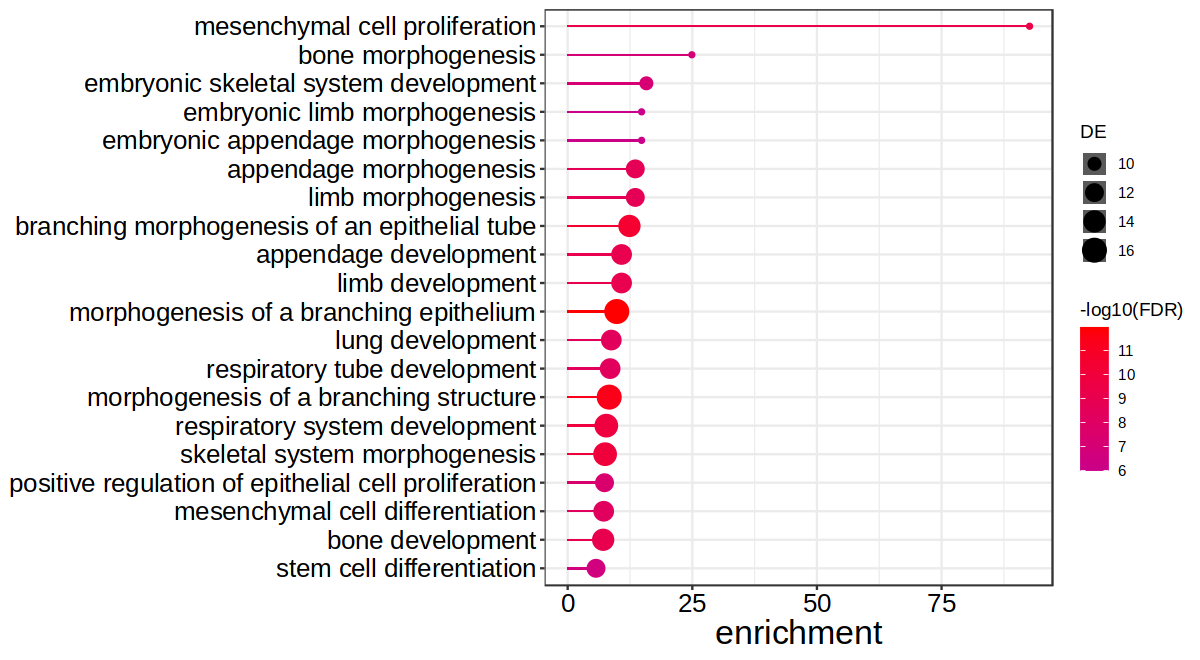

In [287]:
options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

In [288]:
head(go[FDR < 0.05][Ont == 'BP'][enrichment > 5][order(-DE)])

GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0061138,morphogenesis of a branching epithelium,BP,229,16,1.939622e-15,1.056494e-12,9.850308,"Col4a1, Fgfr2, Foxc2, Kdr, Mdk, Mmp14, Nrp1, Pbx1, Pdgfa, Pgf, Sfrp1, Sox2, Sox9, Wnt2, Ctsz, Rdh10"
GO:0001763,morphogenesis of a branching structure,BP,249,16,7.230352e-15,3.846715e-12,8.331479,"Col4a1, Fgfr2, Foxc2, Kdr, Mdk, Mmp14, Nrp1, Pbx1, Pdgfa, Pgf, Sfrp1, Sox2, Sox9, Wnt2, Ctsz, Rdh10"
GO:0048705,skeletal system morphogenesis,BP,254,15,2.690092e-13,1.017208e-10,7.506278,"Cdx1, Col1a1, Fgfr2, Foxc2, Mmp14, Prrx1, Sfrp1, Ski, Sox9, Alx1, Rarb, Irx5, Sp5, Ifitm5, Rdh10"
GO:0060541,respiratory system development,BP,250,15,3.741187e-13,1.337299e-10,7.748400,"Pkdcc, Foxp1, Speg, Fgfr2, Gata6, Kdr, Mmp14, Pdgfa, Ski, Sox2, Sox9, Wnt2, Ctsz, Foxp4, Rdh10"
GO:0048754,branching morphogenesis of an epithelial tube,BP,191,14,6.240463e-14,2.855261e-11,12.389737,"Col4a1, Fgfr2, Foxc2, Kdr, Mdk, Mmp14, Nrp1, Pbx1, Pgf, Sox2, Sox9, Wnt2, Ctsz, Rdh10"
GO:0060348,bone development,BP,252,14,4.003353e-12,9.847819e-10,7.117504,"Foxp1, Cdx1, Col1a1, Fgfr2, Kdr, Meis1, Mmp14, Pdgfa, Ski, Sox9, Rarb, Cadm1, Sp5, Ifitm5"


In [289]:
genes = de.results[variable=='Intermediate_mesoderm' & sig == TRUE & logFC > 0, gene]

In [290]:
# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

'select()' returned 1:many mapping between keys and columns



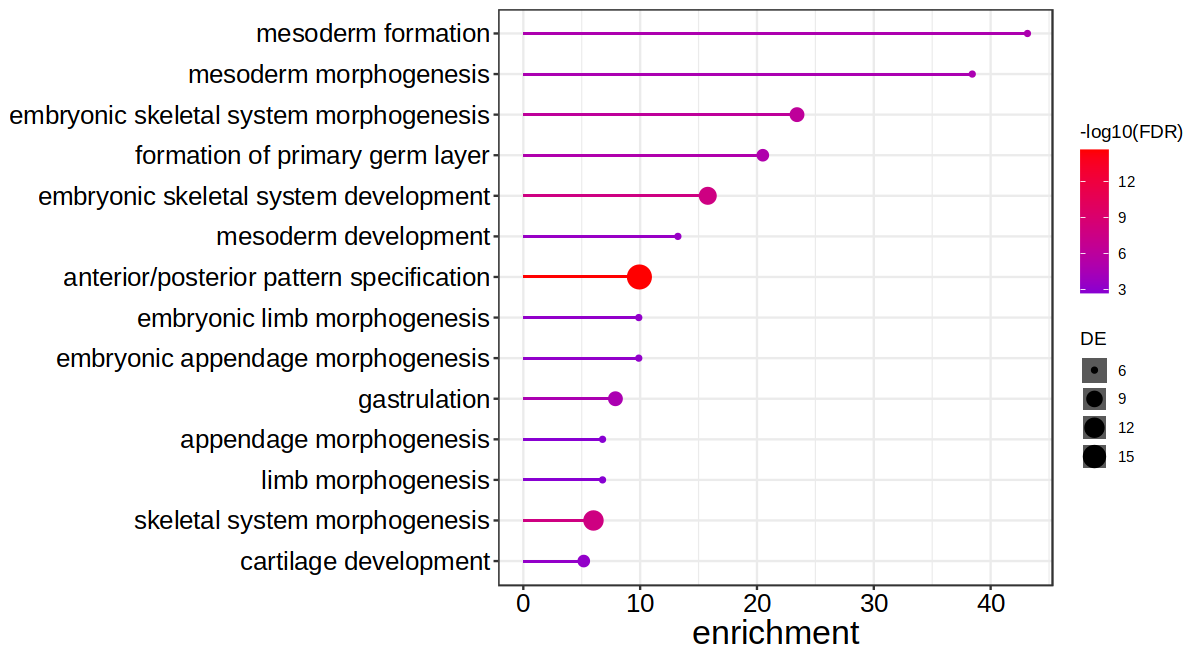

In [291]:
options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

'select()' returned 1:many mapping between keys and columns



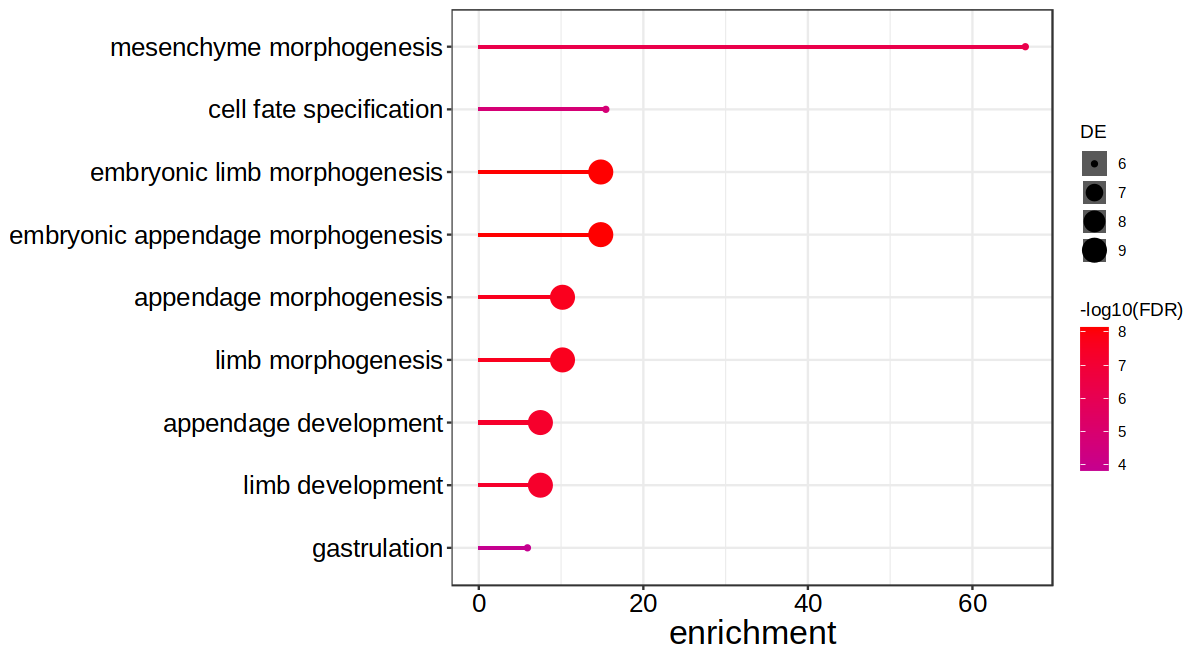

In [300]:
genes = de.results[variable=='Lateral_plate_mesoderm' & sig == TRUE & logFC > 0, gene]

# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

'select()' returned 1:many mapping between keys and columns



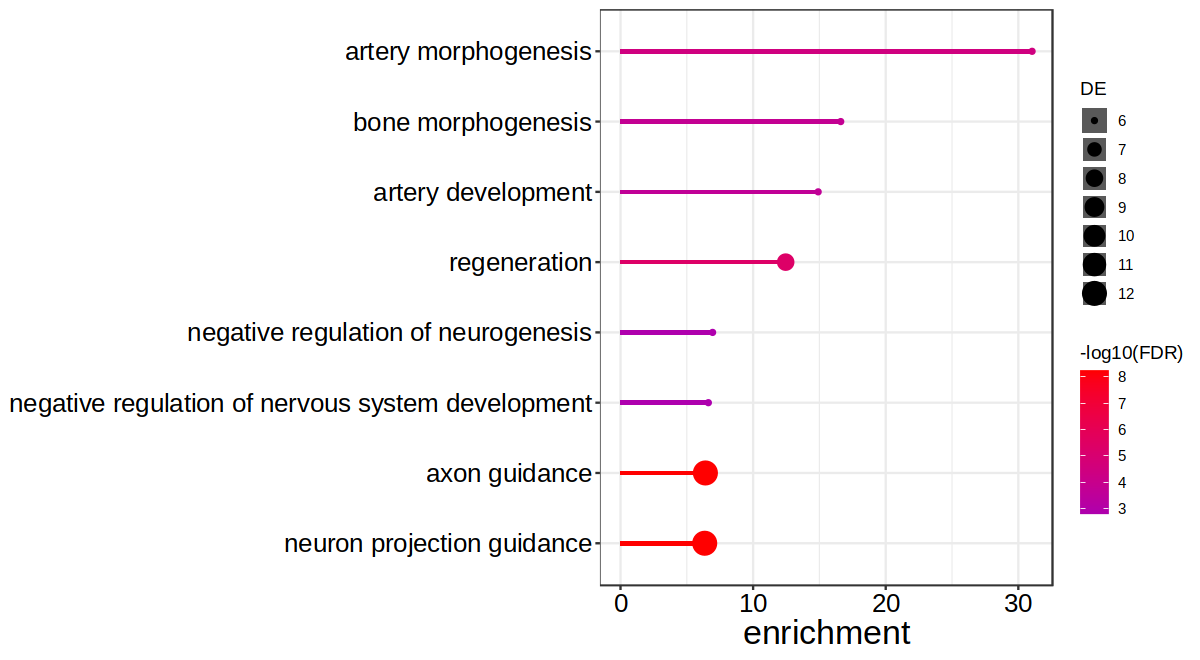

In [301]:
genes = de.results[variable=='Lateral_plate_mesoderm' & sig == TRUE & logFC < 0, gene]

# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 5 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

'select()' returned 1:many mapping between keys and columns



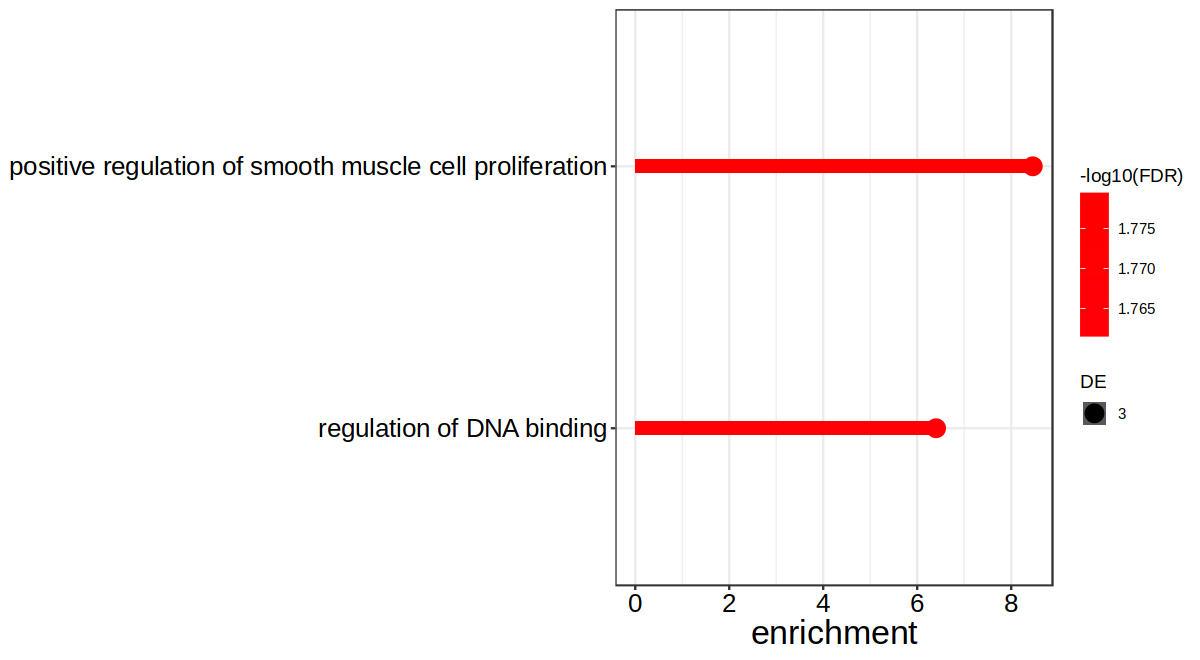

In [316]:
genes = de.results[variable=='Allantois_endothelium' & sig == TRUE & logFC < 0, gene]

# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())

'select()' returned 1:many mapping between keys and columns



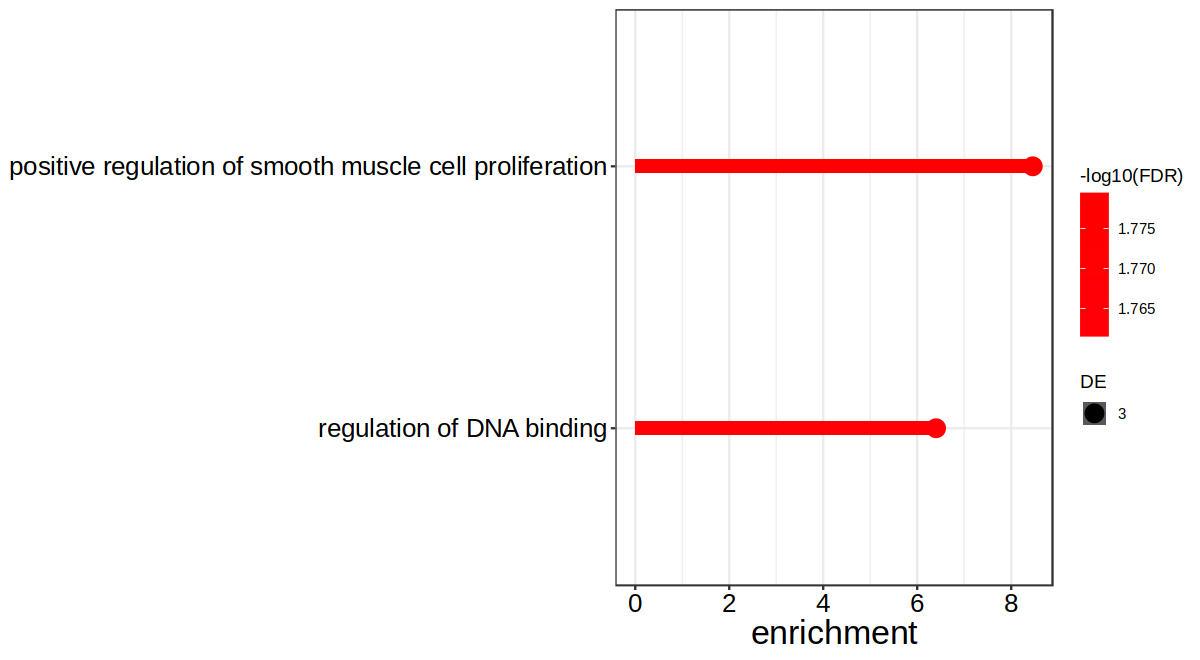

In [317]:
genes = de.results[variable=='Allantois_endothelium' & sig == TRUE & logFC > 0, gene]

# Retrieve GO
go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
    .[order(P.DE)] %>%
    .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
    .[P.DE < 0.1] %>% 
    .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
# Add gene names to annotations
GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
    as.data.table() %>% 
    .[, EVIDENCEALL := NULL] %>% 
    unique() %>% 
    merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
              .[, entrezgene_id := as.character(entrezgene_id)],
          by.x = 'ENTREZID', by.y = 'entrezgene_id')
# Add genes into GO list
go = mclapply(1:nrow(go), function(x){ # nrow(go)
    GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
    genes_GO = intersect(GO_genes_tmp, genes)
    tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                              N = length(intersect(rownames(sce), GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
    .[,enrichment := (DE/N)/(N/32285)] %>% 
    .[, enrichment := ifelse(enrichment > 100, 100, enrichment)]
}, mc.cores = 10) %>% rbindlist()

options(repr.plot.width=10, repr.plot.height=5.5)
plot = go %>% copy() %>% 
       .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & enrichment > 5] %>% .[order(FDR)] %>% 
        head(20) %>% 
        .[order(-enrichment)] %>% 
        .[,Term := factor(Term, levels = rev(Term))]

ggplot(plot, 
       aes(enrichment, Term, color = -log10(FDR), size = DE)) + 
    geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
    geom_point() + 
    scale_color_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    scale_fill_gradient2(low = 'blue', mid = 'blue', high = 'red') + 
    xlim(0, max(plot$enrichment)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
          axis.title.x = element_text(size = 20),
          axis.title.y = element_blank())